# COGS 108 - EDA Checkpoint

## Authors

- Hannah Daniel: Conceptualization, Background research, Writing – original draft  
- Isaac Cordova: Conceptualization, Data curation, Analysis  
- Evenie Osorio: Data curation, Analysis, Visualization  
- Evelyn Cobian: Analysis, Visualization, Writing – review & editing  
- Deandre Juguilon: Project administration, Writing – review & editing  

## Research Question

To what extent is state-level adult diagnosed depression prevalence associated with state-level adult obesity prevalence (BMI ≥ 30) across the 50 U.S. states and DC in 2020?

## Background and Prior Work

Obesity and depression are both major public health issues in the United States and rates of both vary a lot from state to state. Obesity rates have increased over time, while depression is one of the most commonly diagnosed mental health conditions among adults. Since both conditions are influenced by multiple factors like income, access to healthcare, and lifestyle, it is reasonable to think they may be related at a larger population level.

Previous research has looked at the relationship between obesity and depression mostly at the individual level. Many studies have found that people with higher body mass index are more likely to report symptoms of depression. Some research also suggests this relationship may work in both directions, where obesity can increase the risk of depression and depression can also contribute to weight gain through changes in behavior or biological factors.

Researchers have also used geographic data to study health trends across the United States. Public health datasets, such as those collected by the CDC, allow researchers to compare health outcomes across states and identify regional patterns. These datasets are commonly used to examine differences in physical and mental health at the population level.

While obesity and depression have both been studied individually, fewer studies focus on how these two variables relate to each other at the state level. This project aims to explore whether U.S. states with higher obesity rates also tend to report higher rates of diagnosed depression. Examining this relationship at the state level may provide insight into broader public health trends and help guide future research.

## Hypothesis

We hypothesize that there will be a positive linear association between state-level adult diagnosed depression prevalence and state-level adult obesity prevalence (BMI ≥ 30) across the 50 U.S. states and DC in 2020. Specifically, states with higher percentages of adults reporting diagnosed depression will also tend to have higher percentages of adults classified as obese (BMI ≥ 30). This analysis will examine correlation rather than causation.

## Data

### Data overview

For this project, we are using the following dataset:

- **Dataset #1: CDC BRFSS Obesity/Depression Prevalence**
  - **Link:** [CDC BRFSS Data](https://data.cdc.gov/Behavioral-Risk-Factors/BRFSS-Graph-of-Current-Adult-Obesity-Prevalence-Na/tcmp-75zb)
  - **Observations:** 50 states + DC
  - **Variables:** State name, Obesity percentage (BMI > 30.0), Depression percentage

In [1]:
%load_ext autoreload
%autoreload 2

### Dataset

In [2]:
import pandas as pd
import numpy as np
import os

# load raw BRFSS file
df = pd.read_csv('data/00-raw/Behavioral_Risk_Factor_Surveillance_System_(BRFSS)_Prevalence_Data_(2011_to_present)_20260217.csv')

print("raw shape:", df.shape)
df.head()

raw shape: (2760, 27)


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,ResponseID,GeoLocation
0,2020,AK,Alaska,Chronic Health Indicators,Depression,Ever told you that you have a form of depression?,Yes,18-24,Age Group,35,...,NaN,BRFSS,CLASS03,TOPIC17,2,AGE01,CAT3,ADDEPEV3,RESP046,"(64.84507995700051, -147.72205903599973)"
1,2020,AK,Alaska,Chronic Health Indicators,Depression,Ever told you that you have a form of depression?,Yes,25-34,Age Group,88,...,NaN,BRFSS,CLASS03,TOPIC17,2,AGE02,CAT3,ADDEPEV3,RESP046,"(64.84507995700051, -147.72205903599973)"
2,2020,AK,Alaska,Chronic Health Indicators,Depression,Ever told you that you have a form of depression?,Yes,35-44,Age Group,80,...,NaN,BRFSS,CLASS03,TOPIC17,2,AGE03,CAT3,ADDEPEV3,RESP046,"(64.84507995700051, -147.72205903599973)"
3,2020,AK,Alaska,Chronic Health Indicators,Depression,Ever told you that you have a form of depression?,Yes,45-54,Age Group,94,...,NaN,BRFSS,CLASS03,TOPIC17,2,AGE04,CAT3,ADDEPEV3,RESP046,"(64.84507995700051, -147.72205903599973)"
4,2020,AK,Alaska,Chronic Health Indicators,Depression,Ever told you that you have a form of depression?,Yes,55-64,Age Group,117,...,NaN,BRFSS,CLASS03,TOPIC17,2,AGE05,CAT3,ADDEPEV3,RESP046,"(64.84507995700051, -147.72205903599973)"


In [3]:
df.columns

Index(['Year', 'Locationabbr', 'Locationdesc', 'Class', 'Topic', 'Question',
       'Response', 'Break_Out', 'Break_Out_Category', 'Sample_Size',
       'Data_value', 'Confidence_limit_Low', 'Confidence_limit_High',
       'Display_order', 'Data_value_unit', 'Data_value_type',
       'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'DataSource',
       'ClassId', 'TopicId', 'LocationID', 'BreakoutID', 'BreakOutCategoryID',
       'QuestionID', 'ResponseID', 'GeoLocation'],
      dtype='object')

In [4]:
# keep only 2020 (matches our research question)
df_2020 = df[df["Year"] == 2020].copy()
print("after keeping 2020:", df_2020.shape)

# keep only Overall rows (state level, not age or race breakdowns)
df_overall = df_2020[df_2020["Break_Out_Category"] == "Overall"].copy()
print("after keeping Overall:", df_overall.shape)

# keep only the two topics we care about
df_overall = df_overall[df_overall["Topic"].isin(["Depression", "BMI Categories"])].copy()
print("after keeping Topics:", df_overall.shape)

df_overall[["Year", "Locationdesc", "Topic", "Break_Out_Category", "Data_value"]].head()

after keeping 2020: (2760, 27)
after keeping Overall: (110, 27)
after keeping Topics: (110, 27)


,Year,Locationdesc,Topic,Break_Out_Category,Data_value
15,2020,Alaska,Depression,Overall,15.9
41,2020,Alaska,BMI Categories,Overall,31.9
67,2020,Alabama,Depression,Overall,23.5
93,2020,Alabama,BMI Categories,Overall,39.0
119,2020,Arkansas,Depression,Overall,23.5


In [5]:
# remove stuff that isnt one of the 50 states or DC
exclude = ["Guam", "Puerto Rico"]

df_clean = df_overall[~df_overall["Locationdesc"].isin(exclude)].copy()

# remove summary median rows
df_clean = df_clean[~df_clean["Locationdesc"].str.contains("median", case=False, na=False)].copy()

print("after removing territories + median rows:", df_clean.shape)
print("unique locations:", df_clean["Locationdesc"].nunique())
df_clean["Locationdesc"].sort_values().tail(10)

after removing territories + median rows: (102, 27)
unique locations: 51


2463         Virginia
2489         Virginia
2567       Washington
2593       Washington
2671    West Virginia
2697    West Virginia
2619        Wisconsin
2645        Wisconsin
2720          Wyoming
2749          Wyoming
Name: Locationdesc, dtype: object

In [6]:
# should be 51 locations total (50 states + DC)
print("locations:", df_clean["Locationdesc"].nunique())

# should have 51 rows for each topic (51 obesity + 51 depression = 102 total)
print(df_clean["Topic"].value_counts())

# check missingness in the value column we use
df_clean["Data_value"].isna().sum()

locations: 51
Topic
Depression        51
BMI Categories    51
Name: count, dtype: int64


0

In [7]:
# pivot so each state has both values in the same row
df_state = df_clean.pivot_table(
    index="Locationdesc",
    columns="Topic",
    values="Data_value",
    aggfunc="mean"
).reset_index()

print("final df_state shape:", df_state.shape)
df_state.head()

final df_state shape: (51, 3)


Topic,Locationdesc,BMI Categories,Depression
0,Alabama,39.0,23.5
1,Alaska,31.9,15.9
2,Arizona,30.9,17.4
3,Arkansas,36.4,23.5
4,California,30.2,14.1


In [8]:
df_state.isna().sum()

Topic
Locationdesc      0
BMI Categories    0
Depression        0
dtype: int64

In [9]:
# save the processed dataset so EDA can load it easily
os.makedirs("data/02-processed", exist_ok=True)

df_state.to_csv("data/02-processed/state_obesity_depression_2020.csv", index=False)

print("saved:", "data/02-processed/state_obesity_depression_2020.csv")

saved: data/02-processed/state_obesity_depression_2020.csv


### Data Wrangling Explained

We are using CDC BRFSS prevalence data. The raw file includes multiple years and lots of demographic breakouts, so we filtered it down to match our research question.

What we kept:
- Year = 2020
- Break_Out_Category = "Overall" (so it is state level totals, not age or race breakdowns)
- Topic is either "BMI Categories" (obesity, BMI ≥ 30) or "Depression" (diagnosed depression)

What we removed:
- Territories (Guam and Puerto Rico)
- Median summary rows

After that, we reshaped the data so each location has one row with both obesity and depression prevalence.
The final dataset is 51 rows (50 states plus DC) and has no missing values for the variables we use.

### Regrade Fixes (Data Checkpoint)

In the data checkpoint, we received feedback that our dataset description was unclear and that some filtering procedures described in text were not fully reflected in the code.

To address this feedback, we made our cleaning process more explicit and transparent. We now:

- Show the raw dataset shape before filtering.
- Explicitly filter for Year = 2020, Break_Out_Category = "Overall", and the two relevant topics in code.
- Remove territories and verify the final number of locations (51 total).
- Check for missing values in the variables used.
- Reshape the dataset so each state has both obesity and depression prevalence in a single row.
- Save the processed dataset for reproducibility.

These revisions make it clearer how our final dataset aligns directly with our research question and ensure that all data wrangling steps are visible and reproducible.

## Results

### Exploratory Data Analysis

After cleaning and saving the processed dataset, we now load the final state-level dataset to explore the relationship between obesity and depression prevalence across the 50 U.S. states and DC in 2020.

We first examine summary statistics and the distributions of each variable individually. Then we analyze the relationship between depression and obesity using correlation and visualization.

In [10]:
## load processed data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_state = pd.read_csv("data/02-processed/state_obesity_depression_2020.csv")
df_state.head()

,Locationdesc,BMI Categories,Depression
0,Alabama,39.0,23.5
1,Alaska,31.9,15.9
2,Arizona,30.9,17.4
3,Arkansas,36.4,23.5
4,California,30.2,14.1


#### Summary Statistics

In [11]:
df_state.describe()

,BMI Categories,Depression
count,51.000000,51.000000
mean,32.050980,19.515686
std,4.104504,3.152610
min,24.200000,12.700000
25%,28.950000,17.300000
50%,31.900000,19.600000
75%,35.550000,22.050000
max,39.700000,26.400000


##### The average obesity prevalence across states is about 32%, while the average depression prevalence is about 19.5%. Obesity rates range from about 24% to nearly 40%, and depression rates range from about 12% to 26%. This shows there is noticeable variation between states for both variables, which makes it reasonable to examine whether they are related.

#### Distribution Plots

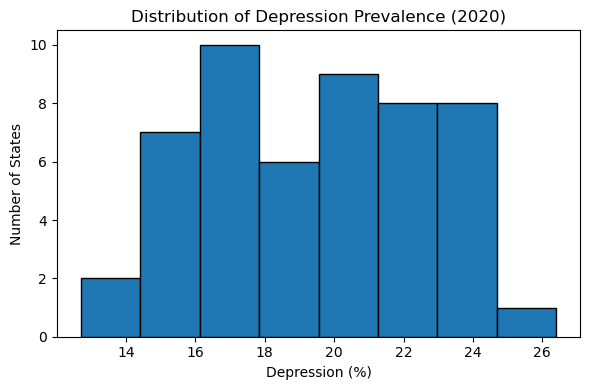

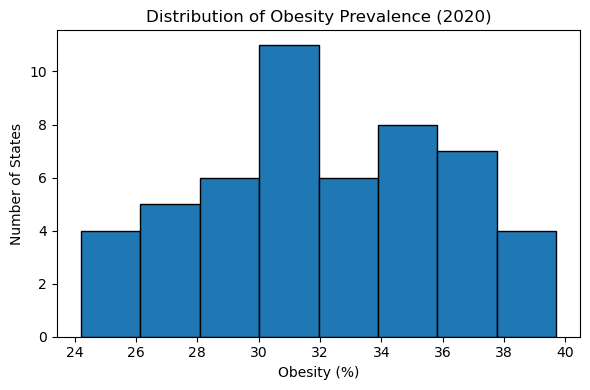

In [12]:
## Distribution plot for depression
plt.figure(figsize=(6,4))
plt.hist(df_state["Depression"], bins=8, edgecolor='black')
plt.title("Distribution of Depression Prevalence (2020)")
plt.xlabel("Depression (%)")
plt.ylabel("Number of States")
plt.tight_layout()
plt.show()

## Distribution plot for obesity
plt.figure(figsize=(6,4))
plt.hist(df_state["BMI Categories"], bins=8, edgecolor='black')
plt.title("Distribution of Obesity Prevalence (2020)")
plt.xlabel("Obesity (%)")
plt.ylabel("Number of States")
plt.tight_layout()
plt.show()

##### Both depression and obesity prevalence appear fairly normally distributed across states, though obesity rates show slightly wider spread. There are no extreme outliers in either variable, which supports using correlation and linear regression to examine their relationship.

#### Correlation Analysis

In [13]:
corr = df_state["BMI Categories"].corr(df_state["Depression"])
print("Correlation:", round(corr, 3))

Correlation: 0.375


##### The correlation coefficient is approximately 0.37, indicating a moderate positive relationship between state-level depression and obesity prevalence. This suggests that states with higher depression rates tend to also have higher obesity rates, though the relationship is not extremely strong.

#### Scatterplot

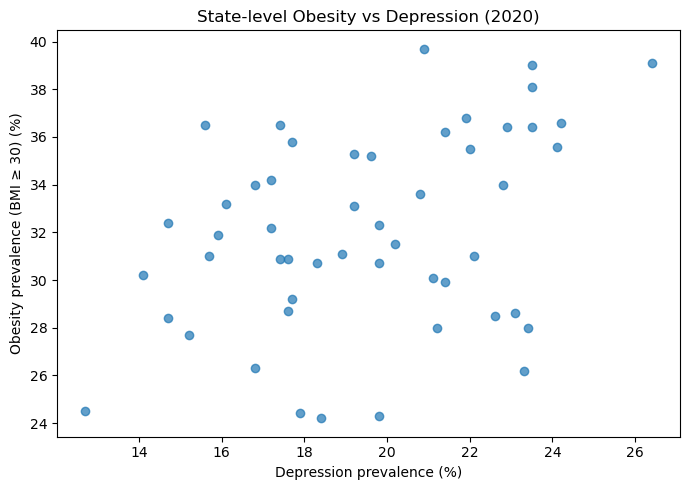

In [14]:
plt.figure(figsize=(7,5))

plt.scatter(
    df_state["Depression"],
    df_state["BMI Categories"],
    alpha=0.7
)

plt.xlabel("Depression prevalence (%)")
plt.ylabel("Obesity prevalence (BMI ≥ 30) (%)")
plt.title("State-level Obesity vs Depression (2020)")
plt.tight_layout()
plt.show()

##### The scatterplot shows a general upward trend, suggesting that states with higher rates of diagnosed depression also tend to have higher obesity prevalence. However, the points are somewhat spread out, indicating that the relationship is not perfectly linear and that other factors likely influence obesity rates across states.

#### Regression Line

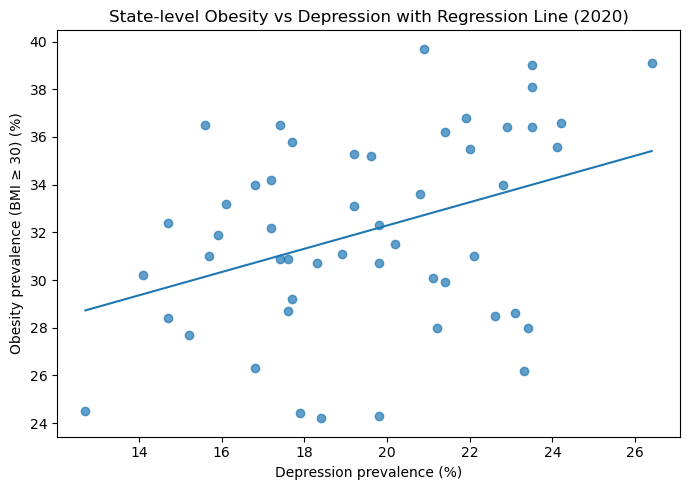

Slope: 0.488
R-squared: 0.14


In [15]:
# calculate regression
m, b = np.polyfit(df_state["Depression"], df_state["BMI Categories"], 1)

# calculate R-squared
r_squared = corr**2

# sort x values for smooth line
x_sorted = np.sort(df_state["Depression"])
y_pred = m * x_sorted + b

plt.figure(figsize=(7,5))

plt.scatter(
    df_state["Depression"],
    df_state["BMI Categories"],
    alpha=0.7
)

plt.plot(x_sorted, y_pred)

plt.xlabel("Depression prevalence (%)")
plt.ylabel("Obesity prevalence (BMI ≥ 30) (%)")
plt.title("State-level Obesity vs Depression with Regression Line (2020)")
plt.tight_layout()
plt.show()

print("Slope:", round(m, 3))
print("R-squared:", round(r_squared, 3))

##### The regression line has a positive slope, which indicates a positive association between depression prevalence and obesity prevalence at the state level. This means that, on average, obesity rates increase as depression rates increase. The R-squared value is approximately 0.14, meaning that around 14% of the variation in obesity rates across states can be explained by differences in depression prevalence. While this suggests a real association, it is not particularly strong, indicating that many other factors likely contribute to obesity rates. These results reflect a population-level trend and should not be interpreted as evidence of causation or individual-level risk.

## Ethics 

### A. Data Collection
 - [X] **A.1 Informed consent**: Participants gave informed consent when the data was originally collected by the CDC. Since we are using state-level summaries, informed consent was already handled by the original researchers.
 - [X] **A.2 Collection bias**: We acknowledge that BRFSS data is self-reported via telephone surveys. This may exclude populations without stable phone access and introduces social desirability bias (underreporting weight or mental health struggles).
 - [X] **A.3 Limit PII exposure**: This project uses aggregated state-level data. No individual-level identifiers are present, ensuring anonymity.
 - [X] **A.4 Downstream bias mitigation**: While our primary analysis is state-level, we will acknowledge that these trends may vary significantly across racial and socioeconomic lines within states.

### B. Data Storage
 - [X] **B.1 Data security**: Data is stored in a secure GitHub repository. We are using public datasets, so no sensitive proprietary data is at risk.
 - [X] **B.2 Right to be forgotten**: Not applicable at the individual level since the data is already anonymized and aggregated by the CDC.
 - [X] **B.3 Data retention plan**: We will retain the data for the duration of the course. If the project is made public, we will ensure it links to the primary CDC source to maintain data freshness.

### C. Analysis
 - [X] **C.1 Missing perspectives**: We acknowledge that BMI is a controversial metric for obesity and may not capture metabolic health accurately for all body types or ethnicities.
 - [X] **C.2 Dataset bias**: We will check for outliers (e.g., states with significantly different reporting standards) to ensure they don't skew the correlation.
 - [X] **C.3 Honest representation**: Our visualizations will use appropriate scales (e.g., not starting Y-axes at non-zero points to exaggerate small differences) to represent the correlation fairly.
 - [X] **C.5 Auditability**: All data cleaning and analysis steps are documented in this notebook, allowing for full reproducibility.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: We will ensure our model does not use state-level variables that might serve as proxies for racial or religious discrimination.
 - [X] **D.4 Explainability**: We will use a simple linear regression model so that the relationship between depression and obesity is easily interpretable by a general audience.
 - [X] **D.5 Communicate limitations**: We will explicitly state that state-level correlation does not imply that an individual with depression will become obese, or vice-versa (avoiding the ecological fallacy).

### E. Deployment
 - [X] **E.4 Unintended use**: We will include a disclaimer that this project is for educational purposes and should not be used to inform personal medical decisions or public health policy without expert consultation.

## Team Expectations 

Our team agrees to communicate regularly through our group chat and schedule meetings as needed to stay on track with deadlines. We will divide tasks based on individual strengths, but everyone is expected to contribute meaningfully to data cleaning, analysis, writing, and reviewing.

We expect all team members to complete their assigned work on time and communicate early if they anticipate any issues. If someone is struggling with a concept or coding issue, we will help each other before the deadline rather than waiting until the last minute.

For major decisions (such as changes to the research question or analysis approach), we will discuss as a group before implementing changes. All team members will review the final submission before pushing to GitHub to ensure accuracy and completeness.

If conflicts arise, we will address them respectfully and prioritize completing the project professionally and collaboratively.

## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|-------------|--------------|--------------------------|--------------------|
| 1/30 | 11:59 PM | Brainstorming | Finalize topic |
| 2/4 | 11:59 PM | Ethics | Submit Proposal |
| 2/18 | 11:59 PM | Data Cleaning | Submit Checkpoint |
| 3/4 | 11:59 PM | EDA | Discuss patterns |
| 3/13 | 11:59 PM | Results draft | Refine visuals |
| 3/18 | 11:59 PM | Final edits | Submit Project |